In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,confusion_matrix


In [11]:
df = sns.load_dataset('iris')

In [12]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [13]:
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])

In [17]:
df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
57,4.9,2.4,3.3,1.0,1
134,6.1,2.6,5.6,1.4,2
97,6.2,2.9,4.3,1.3,1
133,6.3,2.8,5.1,1.5,2
65,6.7,3.1,4.4,1.4,1


In [18]:
df = df[['sepal_length','petal_length','species']]

In [19]:
df.head()

,sepal_length,petal_length,species
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0


In [20]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [22]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state = 2)

In [23]:
clf = LogisticRegression(multi_class='multinomial')
clf.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='multinomial')

In [24]:
y_pred = clf.predict(x_test)

In [25]:
print(accuracy_score(y_test,y_pred))

0.9666666666666667


In [28]:
pd.DataFrame(confusion_matrix(y_test,y_pred))

,0,1,2
0,14,0,0
1,0,7,1
2,0,0,8


In [32]:
# prediction
query = np.array([[3.4,2.7]])

clf.predict_proba(query)


array([[7.25865651e-01, 2.73720718e-01, 4.13631316e-04]])

In [33]:
clf.predict(query)

array([0])

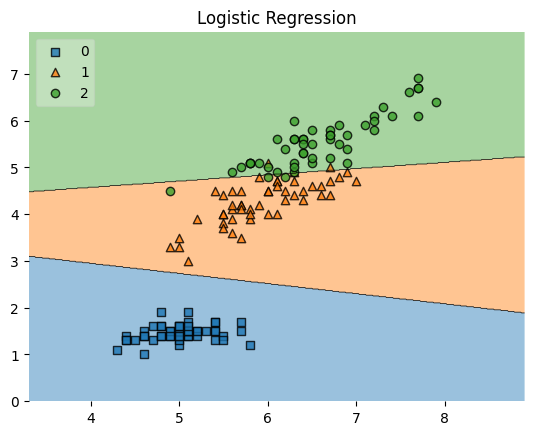

In [35]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(x.values,y.values,clf,legend=2)

plt.xlaebl = 'sepal_length[cm]'
plt.ylabel = 'petal_length[cm]'
plt.title('Logistic Regression')
plt.show()